In [1]:
# Needed if you want to run this code in Google Colab:
%pip install mesa[rec]
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
# Import necessary libraries for data visualization and agent-based modeling
import seaborn as sns
import mesa
import numpy as np

# Boltzmann Wealth Model Tutorial

This notebook demonstrates three increasingly complex versions of the Boltzmann wealth model, an agent-based simulation where wealth is redistributed through random interactions.

Each version builds on the previous one, introducing new concepts. Comments added by AI

### Basic Boltzmann Model with Random Selection and Data Collection

This is the simplest version of the Boltzmann wealth model. In this model, agents (representing people) start with 1 unit of wealth each. At each time step, each agent randomly selects another agent and gives them 1 unit of wealth if they have any.

**Key Concepts:**
- **Agent-Based Modeling**: Each "agent" is an individual entity that can make decisions and interact with others.
- **Random Selection**: Agents choose other agents randomly, simulating unpredictable social interactions.
- **Data Collection**: We track how wealth is distributed over time using Mesa's DataCollector.

In [14]:
class WealthAgent(mesa.Agent):
    """An agent that represents a person with wealth in the Boltzmann model."""

    def __init__(self, model: mesa.Model):
        # Call the parent class constructor to set up the agent
        super().__init__(model)
        # Each agent starts with 1 unit of wealth
        self.wealth = 1

    def give_money(self):
        """Give 1 unit of wealth to a randomly selected other agent, if possible."""
        # Only give money if we have wealth
        if self.wealth > 0:
            # Create a list of all other agents (excluding ourselves)
            other_agents = []
            for agent in self.model.agents:
                if agent is not self:
                    other_agents.append(agent)

            # Randomly choose one of the other agents
            chosen_agent = self.model.random.choice(other_agents)
            # Transfer 1 wealth from self to the chosen agent
            chosen_agent.wealth += 1
            self.wealth -= 1

In [15]:
class WealthModel(mesa.Model):
    """The main model that manages all agents and simulates the Boltzmann wealth distribution."""

    def __init__(self, n_agents):
        # Initialize the parent Mesa model
        super().__init__()
        # Store the number of agents
        if n_agents <= 1:
            raise ValueError(f"More than 1 Agent necessary, you provided only {n_agents} number of Agents")
        self.num_agents = n_agents

        # Create the specified number of WealthAgent instances
        WealthAgent.create_agents(self, self.num_agents)

        # Set up data collection to track wealth over time
        self.datacollector = mesa.DataCollector(
            # Collect each agent's wealth at each step
            agent_reporters={"Wealth": "wealth"},
            # Collect the median wealth across all agents at each step
            model_reporters={"Median": self.get_median_wealth}
        )
        # Collect initial data (step 0)
        self.datacollector.collect(self)

    def step(self):
        """Advance the model by one time step."""
        # Have all agents perform their give_money action in random order
        self.agents.shuffle_do("give_money")
        # Collect data after this step
        self.datacollector.collect(self)

    def get_median_wealth(self):
        """Calculate the median wealth across all agents."""
        # Collect all agents' wealth into a list
        total_wealth = []
        for agent in self.agents:
            total_wealth.append(agent.wealth)
        # Return the median value
        return np.median(total_wealth)

Basic Model - Initial median wealth: 1.0
Basic Model - Final median wealth: 1.0


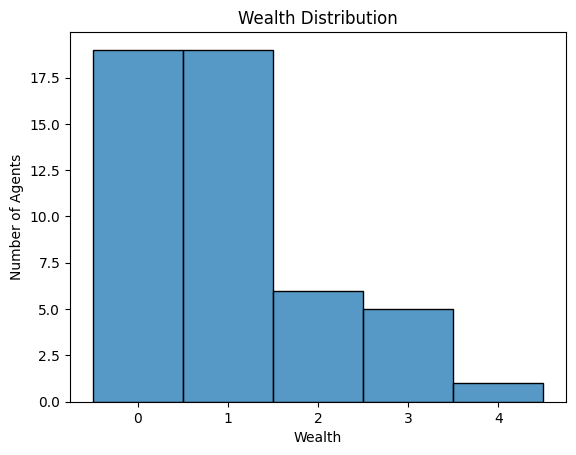

In [5]:
# Create a model with 50 agents
model = WealthModel(n_agents=50)
# Run the simulation for 100 steps
model.run_for(100)

# Get the collected agent data as a pandas DataFrame
agent_data = model.datacollector.get_agent_vars_dataframe()
# Find the last step number
last_step = agent_data.index.get_level_values("Step").max()
# Extract the wealth data from the final step
final_wealth = agent_data.xs(last_step, level="Step")["Wealth"]
# Create a histogram of the final wealth distribution
g = sns.histplot(final_wealth, discrete=True)
g.set(title="Wealth Distribution", xlabel="Wealth", ylabel="Number of Agents")

# Get model data for median analysis
model_data = model.datacollector.get_model_vars_dataframe()
print(f"Basic Model - Initial median wealth: {model_data.loc[0, 'Median']}")
print(f"Basic Model - Final median wealth: {model_data.loc[100, 'Median']}")

### Boltzmann Model with Cell Grid and Data Collection

This version introduces spatial structure to the model. Agents now move around on a grid and can only interact with other agents in the same cell.

**Key Concepts:**
- **Spatial Agent-Based Modeling**: Agents occupy positions in space, which affects their interactions.
- **Grid-Based Movement**: Agents move to random neighboring cells, simulating mobility.
- **Local Interactions**: Wealth transfers only happen between agents in the same cell, making interactions more realistic.
- **CellAgent**: A Mesa class that associates agents with grid cells.

In [6]:
# Import specific Mesa classes for grid-based modeling
# CellAgent: Base class for agents that live on grid cells
# OrthogonalMooreGrid: A grid where cells have 8 neighbors (Moore neighborhood)
from mesa.discrete_space import CellAgent, OrthogonalMooreGrid

In [7]:
class WealthAgent(CellAgent):
    """An agent that lives on a grid cell and can move and interact locally."""

    def __init__(self, model: mesa.Model, cell):
        # Initialize as a CellAgent, which requires a cell reference
        super().__init__(model)
        # Store reference to the cell this agent occupies
        self.cell = cell
        # Start with 1 wealth
        self.wealth = 1

    def move(self):
        """Move to a randomly selected neighboring cell."""
        # Use the cell's neighborhood to pick a random adjacent cell
        self.cell = self.cell.neighborhood.select_random_cell()

    def give_money(self):
        """Give wealth to a random agent in the same cell, if possible."""
        # Get list of other agents in the same cell
        cellmates = []
        for agent in self.cell.agents:
            if agent is not self:
                cellmates.append(agent)

        # If there are other agents in the cell, give money to one randomly
        if cellmates:
            other_agent = self.model.random.choice(cellmates)
            other_agent.wealth += 1
            self.wealth -= 1

    def step(self):
        """Perform one step: move, then potentially give money."""
        # First move to a new cell
        self.move()
        # Then try to give money if we have any
        if self.wealth > 0:
            self.give_money()

In [8]:
class WealthModel(mesa.Model):
    """Model with a grid where agents move and interact locally."""

    def __init__(self, n_agents, width=10, height=10, seed=None):
        # Initialize with a random seed for reproducibility
        super().__init__(rng=seed)
        
        if n_agents <= 1:
            raise ValueError(f"More than 1 Agent necessary, you provided only {n_agents} number of Agents")
        self.num_agents = n_agents
        # Create a grid with the specified dimensions
        self.grid = OrthogonalMooreGrid((width, height), random=self.random)

        # Create agents and randomly place them on grid cells
        # random.choices selects cells with replacement, so multiple agents can start in same cell
        WealthAgent.create_agents(self, self.num_agents, self.random.choices(self.grid.all_cells.cells, k=self.num_agents))

        # Set up data collection
        self.datacollector = mesa.DataCollector(
            agent_reporters={"Wealth": "wealth"},
            model_reporters={"Median": self.get_median_wealth}
        )
        self.datacollector.collect(self)

    def step(self):
        """Advance the model by one step."""
        # Have all agents perform their step method in random order
        self.agents.shuffle_do("step")
        self.datacollector.collect(self)

    def get_median_wealth(self):
        """Calculate median wealth across all agents."""
        total_wealth = []
        for agent in self.agents:
            total_wealth.append(agent.wealth)
        return np.median(total_wealth)

Grid Model - Initial median wealth: 1.0
Grid Model - Final median wealth: 1.0


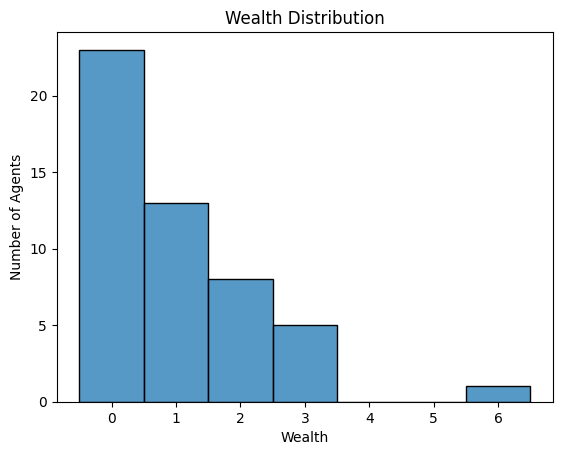

In [9]:
# Create model with 50 agents on a 15x12 grid, using seed for reproducibility
model = WealthModel(n_agents=50, width=15, height=12, seed=123)
# Run for 100 steps
model.run_for(100)

# Extract and plot final wealth distribution
agent_data = model.datacollector.get_agent_vars_dataframe()
last_step = agent_data.index.get_level_values("Step").max()
final_wealth = agent_data.xs(last_step, level="Step")["Wealth"]
g = sns.histplot(final_wealth, discrete=True)
g.set(title="Wealth Distribution", xlabel="Wealth", ylabel="Number of Agents")

# Get model data for median analysis
model_data = model.datacollector.get_model_vars_dataframe()
print(f"Grid Model - Initial median wealth: {model_data.loc[0, 'Median']}")
print(f"Grid Model - Final median wealth: {model_data.loc[100, 'Median']}")

### Advanced Boltzmann Model with Parameter Class and List Comprehensions

This final version demonstrates more advanced Python features and better code organization. It uses a dataclass for parameters and list comprehensions for cleaner code.

**Key Concepts:**
- **Dataclasses**: A Python feature for creating classes that mainly store data, with automatic methods like __init__.
- **List Comprehensions**: A concise way to create lists from existing iterables, more readable than traditional loops.
- **Parameter Management**: Using a separate class to handle model parameters makes the code more modular and easier to modify.
- **Code Efficiency**: List comprehensions are often faster and more Pythonic than equivalent loops.

In [10]:
# Import dataclass decorator for creating parameter classes
from dataclasses import dataclass

In [11]:
class WealthAgent(CellAgent):
    """Agent for the advanced Boltzmann model with improved code style."""

    def __init__(self, model: mesa.Model, cell):
        super().__init__(model)
        self.cell = cell
        self.wealth = 1

    def move(self):
        """Move to a random neighboring cell."""
        self.cell = self.cell.neighborhood.select_random_cell()

    def give_money(self):
        """Give wealth to a random cellmate using list comprehension."""
        # Use list comprehension to create list of other agents in cell
        # More concise and Pythonic than the traditional for loop
        cellmates = [agent for agent in self.cell.agents if agent is not self]

        if cellmates:
            other_agent = self.model.random.choice(cellmates)
            other_agent.wealth += 1
            self.wealth -= 1

    def step(self):
        """Perform move and give_money actions."""
        self.move()
        if self.wealth > 0:
            self.give_money()

In [12]:
# Define a dataclass to hold model parameters
# Dataclasses automatically generate __init__, __repr__, etc.
@dataclass
class ModelParameters:
    """Container for all model configuration parameters."""
    num_agents: int  # Number of agents in the simulation
    grid_width: int = 10  # Width of the grid (default 10)
    grid_height: int = 10  # Height of the grid (default 10)
    seed: int = 1234  # Random seed for reproducibility (default 1234)

class WealthModel(mesa.Model):
    """Advanced wealth model using parameter class and efficient code."""

    def __init__(self, model_parameters: ModelParameters):
        # Initialize with parameters from the dataclass
        super().__init__(rng=model_parameters.seed)

        if model_parameters.num_agents <= 1:
            raise ValueError(f"More than 1 Agent necessary, you provided only {model_parameters.num_agents} number of Agents")
        self.num_agents = model_parameters.num_agents
        # Create grid using parameters
        self.grid = OrthogonalMooreGrid((model_parameters.grid_width, model_parameters.grid_height), random=self.random)

        # Place agents randomly on the grid
        WealthAgent.create_agents(self, self.num_agents, self.random.choices(self.grid.all_cells.cells, k=self.num_agents))

        # Set up data collection
        self.datacollector = mesa.DataCollector(
            agent_reporters={"Wealth": "wealth"},
            model_reporters={"Median": self.get_median_wealth}
        )
        self.datacollector.collect(self)

    def step(self):
        """Advance the model by one step."""
        self.agents.shuffle_do("step")
        self.datacollector.collect(self)

    def get_median_wealth(self):
        """Calculate median wealth using list comprehension for efficiency."""
        # List comprehension is more concise and often faster than a for loop
        return np.median([agent.wealth for agent in self.agents])

Advanced Model - Initial median wealth: 1.0
Advanced Model - Final median wealth: 0.0


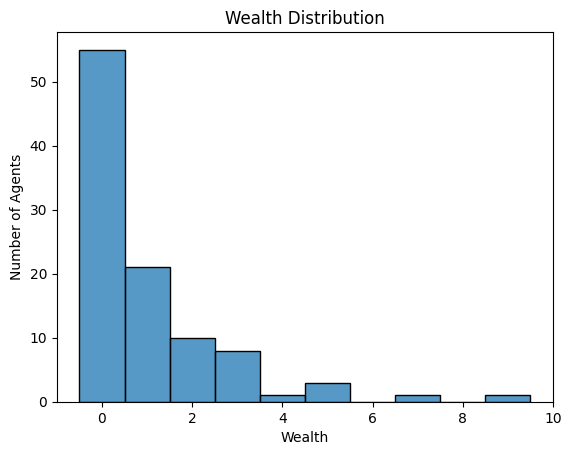

In [13]:
# Create parameter object with custom values
parameters = ModelParameters(num_agents=100,
                             grid_width=20,
                             grid_height=15,
                             seed=1234)
# Initialize model with the parameter object
model = WealthModel(parameters)
# Run simulation
model.run_for(100)

# Analyze results
agent_data = model.datacollector.get_agent_vars_dataframe()
last_step = agent_data.index.get_level_values("Step").max()
final_wealth = agent_data.xs(last_step, level="Step")["Wealth"]
g = sns.histplot(final_wealth, discrete=True)
g.set(title="Wealth Distribution", xlabel="Wealth", ylabel="Number of Agents")

# Get model data for median analysis
model_data = model.datacollector.get_model_vars_dataframe()
print(f"Advanced Model - Initial median wealth: {model_data.loc[0, 'Median']}")
print(f"Advanced Model - Final median wealth: {model_data.loc[100, 'Median']}")